# Local Housing Price Nowcasting
## Econ 148 — Group Project

**Goal.** Build a monthly **nowcast** of local house-price changes for three
structurally different U.S. metros — **San Francisco, Austin, Cleveland** —
and test whether non-linear models (XGBoost, a 2-layer MLP) extract signal
beyond classical linear / time-series baselines (OLS, ARIMA).

**Target.** Monthly log return of the Zillow Home Value Index:
$$y_t \;=\; \ln\!\left(\frac{\text{ZHVI}_t}{\text{ZHVI}_{t-1}}\right).$$

**Data sources.**
| Series | Source | Frequency |
|---|---|---|
| ZHVI, new listings, days-to-pending, price cuts | Zillow Research | Monthly (metro) |
| 30-yr mortgage rate, UNRATE, CPI, housing starts, STLFSI | FRED | Weekly / monthly |
| Metro-level unemployment (LAUS, SA) | FRED | Monthly (metro) |
| Median income, median home value, vacancy rate | Census ACS 5-yr 2024 | One snapshot |

**Design choices.**
- The 2024 ACS is a single cross-section, so it functions as a **per-metro
  fixed effect / structural bias**, not a time-varying covariate.
- Leading indicators are **lagged one month** so the model uses information
  that was actually available at nowcast time.
- A single chronological split (**train ≤ 2022-12**, **test 2023-01 →
  latest**) means the test window covers the 2023+ rate-shock regime — a
  genuine out-of-distribution stress test.


## 0. Setup

This cell load all the tools and libraries the notebook need to run and sets up the folder paths.

Libraries :
  - `numpy` and `pandas` support numerical operations and data manipulation
  - `pandas_datareader` collects live data from the FRED API
  - `statsmodels` handles OLS regression and ARIMA
  - `matplotlib` support all the visualization
  - `xgboost` and `sklearn` execute linear models
  - `shap` compute feature attributions

Reproducibility : to ensure full Run All we set `SEED = 0` and pass it to every operations so all bit are identical reproduced accross machines and sessions.

Path :
  - `ROOT` resolves to the repository root regardless of the working directory.
  - `RAW` points to "/data/raw/' for inputs datasets.
  - `OUT_FIG` and `OUT_TAB` points to "outputs/tables/" for all saved results.

Study design :
  - `METROS` matches each city name with its FRED LAUS unemployment serie ID and its Census ACS region label.
  - `TEST_START` and `TRAIN_END` defines the time focus : from December 2022 to January 2023.


In [4]:
!git clone https://github.com/garavels/ECON-148.git
import os
os.chdir("ECON-148")

Cloning into 'ECON-148'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 76 (delta 5), reused 62 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 6.17 MiB | 17.63 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [5]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pandas_datareader import data as pdr

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

import xgboost as xgb
import shap

from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 0
np.random.seed(SEED)

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
OUT_FIG = ROOT / "outputs" / "figures"; OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB = ROOT / "outputs" / "tables";  OUT_TAB.mkdir(parents=True, exist_ok=True)

# --- Targets of analysis ------------------------------------------------
METROS = {
    "San Francisco, CA": {"laus": "SANF806URN", "acs": "San Francisco-Oakland-Fremont"},
    "Austin, TX":        {"laus": "AUST448URN", "acs": "Austin-Round Rock"},
    "Cleveland, OH":     {"laus": "CLEV439URN", "acs": "Cleveland, OH Metro Area"},
}
METRO_NAMES = list(METROS)

START, END = "2000-01-01", "2026-03-31"
TRAIN_END, TEST_START = "2022-12-31", "2023-01-01"


## 1. Load raw data

The raw inputs live in `data/raw/`. For series that also have a FRED API
endpoint (the macro series and metro LAUS unemployment), we prefer a live
`pandas_datareader` pull so the notebook stays up-to-date without manual
re-downloads.


### 1.1 Zillow metro panel

Zillow publishes monthly CSVs in **wide** format CVs : one row per city, one column per month.
We reshape each one to **long** format (one row per city per mont)  with `melt`. We also convert the date columns to month-end timestamps, and join the four metro-level series together.

Four different series are loaded here :
  - `zhvi` : Zillow Home Value Index - seasonaly adujsted median home value index.
  - `new_listing` : reports the count of newly listed homes in each months.
  - `days_pending` : measure of market pace based on the median number of days from listing to pending sale.
  - `price_cuts` : measure of seller pressure based on the share of active listing with a price reduction.


In [37]:
ZILLOW_FILES = {
    "zhvi":         "Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv",
    "new_listings": "Metro_new_listings_uc_sfrcondo_sm_month.csv",
    "days_pending": "Metro_med_doz_pending_uc_sfrcondo_sm_month.csv",
    "price_cuts":   "Metro_perc_listings_price_cut_uc_sfrcondo_sm_month.csv",
}
ID_COLS = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]


def read_zillow_csv(filename: str) -> pd.DataFrame:
    """Read a Zillow wide CSV and filter to our three metros."""
    df = pd.read_csv(RAW / filename)
    date_cols = [c for c in df.columns if c.startswith(("19", "20"))]
    return df[df["RegionName"].isin(METRO_NAMES)], date_cols


def melt_zillow(df, date_cols, value_name: str) -> pd.DataFrame:
    """Melt wide Zillow data to long format with month-end dates."""
    return (
        df.melt(id_vars=ID_COLS, value_vars=date_cols,
                var_name="date", value_name=value_name)
        .assign(date=lambda d: pd.to_datetime(d["date"]).dt.to_period("M").dt.to_timestamp("M"))
        .rename(columns={"RegionName": "metro"})
        [["metro", "date", value_name]]
    )

def load_zillow_series(filename: str, value_name: str) -> pd.DataFrame:
    """Load and reshape one Zillow CSV to long format."""
    df, date_cols = read_zillow_csv(filename)
    return melt_zillow(df, date_cols, value_name)


zillow = load_zillow_series(ZILLOW_FILES["zhvi"], "zhvi")
for key in ["new_listings", "days_pending", "price_cuts"]:
    zillow = zillow.merge(
        load_zillow_series(ZILLOW_FILES[key], key),
        on=["metro", "date"], how="outer",
    )

zillow = zillow.sort_values(["metro", "date"]).reset_index(drop=True)
print(f"Zillow panel: {zillow.shape[0]:,} rows  ×  {zillow.shape[1]} cols")
zillow.tail(4)


Zillow panel: 945 rows  ×  6 cols


,metro,date,zhvi,new_listings,days_pending,price_cuts
941,"San Francisco, CA",2025-12-31,"1,136,832.2679","1,766.0000",29.0000,0.1711
942,"San Francisco, CA",2026-01-31,"1,139,902.4047","1,580.0000",28.0000,0.1468
943,"San Francisco, CA",2026-02-28,"1,142,085.7317","2,022.0000",24.0000,0.1348
944,"San Francisco, CA",2026-03-31,"1,143,246.4124","2,987.0000",15.0000,0.1483


### Sanity check and important constraint :

The is cell identifies the earlies non-null observation date for each variable and each metro. The output should confirm which variables are available starting 2000 and which ones are constrained to 2018 onward.

In [7]:
coverage = (
    zillow.set_index(["metro", "date"])
          .notna()
          .groupby("metro")
          .apply(lambda g: g.apply(lambda col: col[col].index.get_level_values("date").min()))
)
coverage


,zhvi,new_listings,days_pending,price_cuts
metro,,,,
"Austin, TX",2000-01-31,2018-03-31,2018-03-31,2018-03-31
"Cleveland, OH",2000-01-31,2018-03-31,2018-03-31,2018-03-31
"San Francisco, CA",2000-01-31,2018-03-31,2018-03-31,2018-03-31


### Plot — ZHVI trajectories

We plot a chart to illustrate ZHVI price level trajectories by Metro. Due to the divergent dynamics of each city, we can use a single pooled model on a shared axis. Each city trajectory is illustrated by a different line. The y-axis is formatted in thousands of dollars. This figure is saved to outputs/figures/zhvi_levels.png.

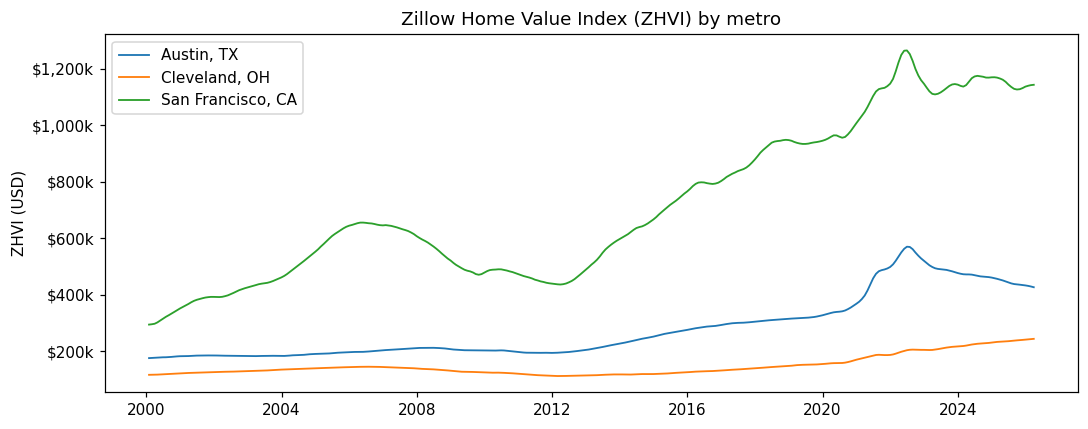

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for metro, g in zillow.groupby("metro"):
    ax.plot(g["date"], g["zhvi"], label=metro, lw=1.2)
ax.set_title("Zillow Home Value Index (ZHVI) by metro")
ax.set_ylabel("ZHVI (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG / "zhvi_levels.png", dpi=150)
plt.show()


### 1.2 FRED national macro series

We retrieve five national series from FRED. The API is keyless via
`pandas_datareader` :
  - `MORTGAGE30US` - 30-year fixed mortgage rate.
  - `UNRATE` - Monthly and seasonally adjusted national unemployment rate.
  - `CPIAUCSL` - Monthly urban consumers price index.
  - `HOUST` - monthly new privately-owned housing units started (thousands)
  - `STLFI4` - St. Louis Fed Financial Stress Index.

We resample weekly series (`MORTGAGE30US`, `STLFSI4`) to mont-end means to align with the Zillow and LAUS monthly timeline.

Reproducibility :  If the live API call fails, `fetch_fred()` enables to fall back to the CSVs downloaded in `data/raw/` to ensure full offline reproducibility.

In [9]:
FRED_SERIES = ["MORTGAGE30US", "UNRATE", "CPIAUCSL", "HOUST", "STLFSI4"]
FRED_CSV = {
    "MORTGAGE30US": "MORTGAGE30US.csv", "UNRATE": "UNRATE.csv",
    "CPIAUCSL": "CPIAUCSL.csv",       "HOUST":  "HOUST.csv",
    "STLFSI4":  "STLFSI4.csv",
}


def fetch_fred(series: str) -> pd.Series:
    try:
        return pdr.DataReader(series, "fred", START, END)[series]
    except Exception as e:
        print(f"  [{series}] API failed ({e.__class__.__name__}) — using CSV fallback")
        df = pd.read_csv(RAW / FRED_CSV[series], parse_dates=["observation_date"])
        return pd.to_numeric(df[series], errors="coerce").set_axis(df["observation_date"])


fred_monthly = pd.concat(
    {s: fetch_fred(s).resample("ME").mean() for s in FRED_SERIES},
    axis=1,
)
fred_monthly.index.name = "date"
print(f"FRED monthly panel: {fred_monthly.shape}")
fred_monthly.tail(5)


FRED monthly panel: (315, 5)


,MORTGAGE30US,UNRATE,CPIAUCSL,HOUST,STLFSI4
date,,,,,
2025-11-30,6.2375,4.5000,325.0630,"1,324.0000",-0.3383
2025-12-31,6.1900,4.4000,326.0310,"1,387.0000",-0.4262
2026-01-31,6.1025,4.3000,326.5880,"1,487.0000",-0.6532
2026-02-28,6.0475,4.4000,327.4600,NaN,-0.5516
2026-03-31,6.1775,4.3000,330.2930,NaN,-0.3191


### Plot — National Macroeconomic Context

We plot a five-panel vertically stacked layout chart to highlight the economic backdrop against which our owcasting models are trained and tested. All five FRED series shared a same time-axis. The x-axis uses five-year tick intervals.

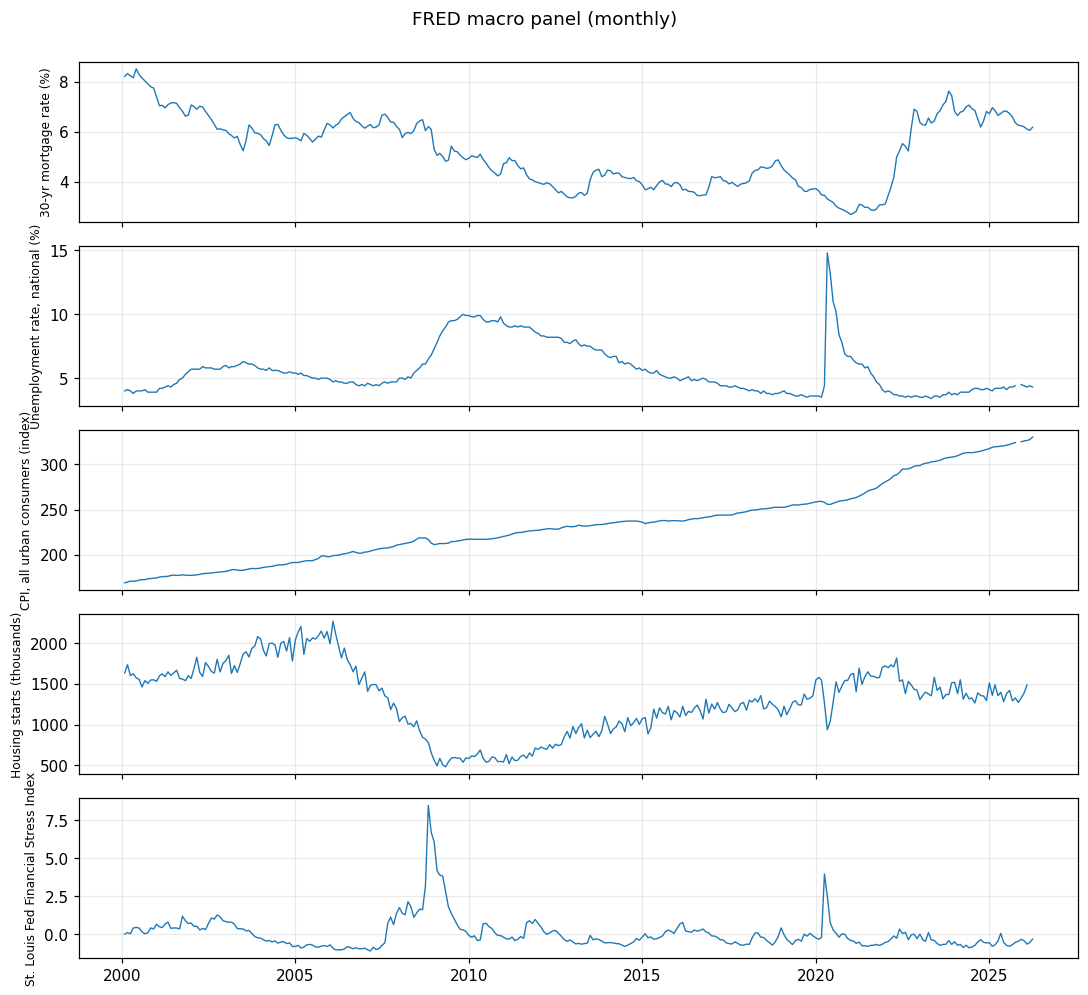

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
series_info = [
    ("MORTGAGE30US", "30-yr mortgage rate (%)"),
    ("UNRATE",       "Unemployment rate, national (%)"),
    ("CPIAUCSL",     "CPI, all urban consumers (index)"),
    ("HOUST",        "Housing starts (thousands)"),
    ("STLFSI4",      "St. Louis Fed Financial Stress Index"),
]
for ax, (col, label) in zip(axes, series_info):
    ax.plot(fred_monthly.index, fred_monthly[col], lw=0.9)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(alpha=0.25)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
fig.suptitle("FRED macro panel (monthly)", y=1.00)
fig.tight_layout()
fig.savefig(OUT_FIG / "fred_macro.png", dpi=150)
plt.show()


### 1.3 Metro-level unemployment (LAUS)

National UNRATE applies equally to all three metros which prevent us from distinguishing local dynamics.
In this cell, we pull a separate unemployment series for each metro from FRED using LAUS : the **metro-level** Local Area Unemployment Statistics (LAUS) series, seasonally adjusted,so the model can see that Cleveland's labour market behaves differently from Austin's.
Results are stored in dataframe keyed on metro x date.


In [11]:
metro_unrate_frames = []
for metro, meta in METROS.items():
    s = pdr.DataReader(meta["laus"], "fred", START, END)[meta["laus"]]
    metro_unrate_frames.append(
        pd.DataFrame({
            "metro": metro,
            "date": s.index.to_period("M").to_timestamp("M"),
            "unrate_metro": s.values,
        })
    )

metro_unrate = pd.concat(metro_unrate_frames, ignore_index=True)
print(f"Metro LAUS panel: {metro_unrate.shape}")
metro_unrate.groupby("metro")["unrate_metro"].describe().round(2)


Metro LAUS panel: (926, 3)


,count,mean,std,min,25%,50%,75%,max
metro,,,,,,,,
"Austin, TX",312.0000,4.5000,1.4900,2.4000,3.4000,4.0500,5.5000,11.5000
"Cleveland, OH",300.0000,5.5700,1.9100,2.1000,4.5000,5.3000,6.3200,20.6000
"San Francisco, CA",312.0000,5.3700,2.2500,2.3000,3.8000,4.6000,6.4300,13.9000


### Plot - Metro vs National Unemployment Plot

We plot the three metro-level LAUS series alongside the national UNRATE (dashed black line) on a shared axis. The figure is saved to outputs/figures/unrate_metro.png.

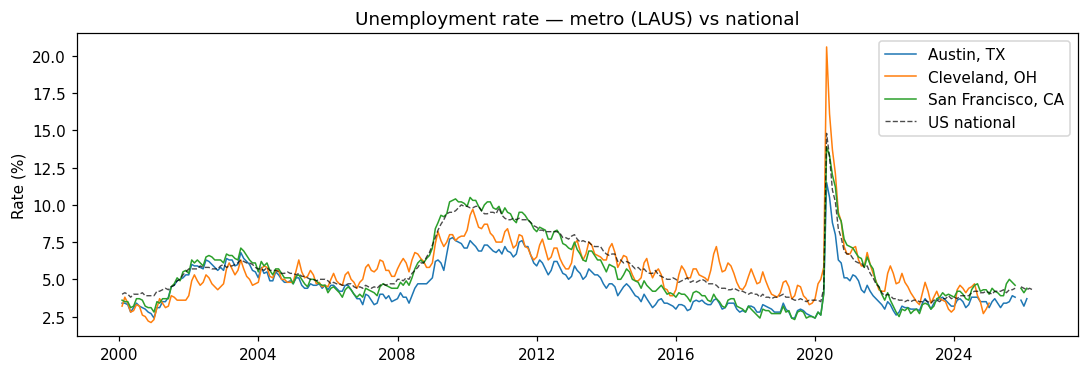

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for metro, g in metro_unrate.groupby("metro"):
    ax.plot(g["date"], g["unrate_metro"], label=metro, lw=1.0)
ax.plot(fred_monthly.index, fred_monthly["UNRATE"],
        label="US national", color="black", ls="--", lw=0.9, alpha=0.7)
ax.set_title("Unemployment rate — metro (LAUS) vs national")
ax.set_ylabel("Rate (%)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG / "unrate_metro.png", dpi=150)
plt.show()


### 1.4 Census ACS static features (2024)

The 2024 ACS is a single snapshot, so its three variables below enter the
model as **per-metro fixed effects** — they absorb structural differences
between the metros but carry no temporal variation.

We read three ACS tables from CSV and extracts one value per metro for each variable. The three variables extracted are :
  - `acs_median_income` from table S1901.
  - `acs_median_home_value` from table B25077.
  - `acs_vacancy_rate` from table DP04.

| Variable | ACS table | Role |
|---|---|---|
| Median household income | S1901 | Proxy for purchasing power |
| Median home value | B25077 | Price level anchor |
| Vacancy rate (%) | DP04 | Supply slack |

We also use 3 helper functions to help us formatting the ACS files :
  - `parse_number()` removes non-numeric characters and codes
  - `find_col()` locates the correct column by keyword matching
  - `pick_metro_value()` finds correct row by label and returns the parsed value

In [13]:
import re

def parse_number(x) -> float:
    if pd.isna(x) or str(x).strip() in {"-", "(X)", "N", ""}:
        return np.nan
    s = re.sub(r"[^\d.\-]", "", str(x))
    return float(s) if s else np.nan


def find_col(columns, needle, suffix):
    for c in columns:
        if needle in c and c.endswith(suffix):
            return c
    return None


def pick_metro_value(df: pd.DataFrame, needle: str, suffix: str,
                    row_contains: str) -> float:
    col = find_col(df.columns, needle, suffix)
    if col is None:
        return np.nan
    label = df.columns[0]
    hit = df[df[label].astype(str).str.contains(row_contains, na=False)]
    return parse_number(hit.iloc[0][col]) if not hit.empty else np.nan


s1901 = pd.read_csv(RAW / "ACSST5Y2024.S1901-2026-04-20T012535.csv")
b25077 = pd.read_csv(RAW / "ACSDT5Y2024.B25077-2026-04-20T011959.csv")
dp04 = pd.read_csv(RAW / "ACSDP5Y2024.DP04-2026-04-20T011849.csv")

acs = pd.DataFrame([
    {
        "metro": metro,
        "acs_median_income": pick_metro_value(
            s1901, meta["acs"], "Households!!Estimate", "Median income"
        ),
        "acs_median_home_value": pick_metro_value(
            b25077, meta["acs"], "Estimate", "Median value"
        ),
        "acs_vacancy_rate": pick_metro_value(
            dp04, meta["acs"], "Percent", "Vacant housing units"
        ),
    }
    for metro, meta in METROS.items()
])
acs


,metro,acs_median_income,acs_median_home_value,acs_vacancy_rate
0,"San Francisco, CA","108,092.0000","1,140,700.0000",7.2000
1,"Austin, TX","100,431.0000","465,000.0000",5.1000
2,"Cleveland, OH","40,801.0000","102,000.0000",15.6000


### 1.5 Assembling the Master Panel

We merge all four data source into a single-long format dataframe indexed by metro x date. We join it in the following order :
1. Zillow metro panel (`metro × date`) : base table
2. FRED national macro (`date` only) : left join on date, broadcasted across metros
3. join metro LAUS (keyed on `metro × date`) : left join on both keys
4. join ACS static features (keyed on `metro` only) : left join on metro and repeated across all months.

Rows are sorted by metro then date and the index is reset.

In [14]:
fred_long = fred_monthly.reset_index().assign(
    date=lambda d: pd.to_datetime(d["date"]).dt.to_period("M").dt.to_timestamp("M")
)

panel = (
    zillow
    .merge(fred_long, on="date", how="left")
    .merge(metro_unrate, on=["metro", "date"], how="left")
    .merge(acs, on="metro", how="left")
    .sort_values(["metro", "date"])
    .reset_index(drop=True)
)

print(f"Master panel: {panel.shape[0]:,} rows × {panel.shape[1]} cols")
print(f"Dates: {panel['date'].min():%Y-%m} → {panel['date'].max():%Y-%m}")
panel.head(3)


Master panel: 945 rows × 15 cols
Dates: 2000-01 → 2026-03


,metro,date,zhvi,new_listings,days_pending,price_cuts,MORTGAGE30US,UNRATE,CPIAUCSL,HOUST,STLFSI4,unrate_metro,acs_median_income,acs_median_home_value,acs_vacancy_rate
0,"Austin, TX",2000-01-31,"176,345.2543",NaN,NaN,NaN,8.2100,4.0000,169.3000,"1,636.0000",0.0051,3.4000,"100,431.0000","465,000.0000",5.1000
1,"Austin, TX",2000-02-29,"176,925.1289",NaN,NaN,NaN,8.3250,4.1000,170.0000,"1,737.0000",0.1106,3.4000,"100,431.0000","465,000.0000",5.1000
2,"Austin, TX",2000-03-31,"177,456.0825",NaN,NaN,NaN,8.2400,4.0000,171.0000,"1,604.0000",0.0243,3.3000,"100,431.0000","465,000.0000",5.1000


### Plot — missingness heatmap

We visualize missingness before any modelling step makes the 2018 Zillow
listings boundary obvious and prevents us from being surprised later when
training rows evaporate.
We compute the share of missing values per column per year and displays the result as a heatmap. Dark cells indicate full data, light cells means that missing data are present. The figure is saved to outputs/figures/missingness.png.


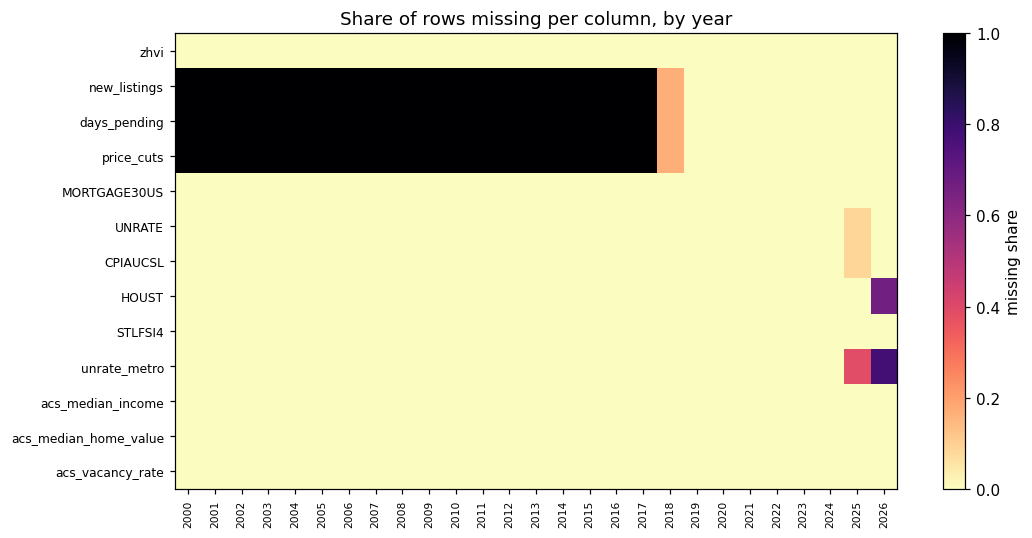

In [15]:
missing = (
    panel
    .assign(year=panel["date"].dt.year)
    .groupby("year")
    .apply(lambda g: g.drop(columns=["metro", "date", "year"]).isna().mean())
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(missing.T, aspect="auto", cmap="magma_r", vmin=0, vmax=1)
ax.set_yticks(range(len(missing.columns)))
ax.set_yticklabels(missing.columns, fontsize=8)
ax.set_xticks(range(len(missing.index)))
ax.set_xticklabels(missing.index, rotation=90, fontsize=7)
ax.set_title("Share of rows missing per column, by year")
fig.colorbar(im, ax=ax, label="missing share")
fig.tight_layout()
fig.savefig(OUT_FIG / "missingness.png", dpi=150)
plt.show()


## 2. Feature engineering

The raw panel is not directly usable: **ZHVI in dollars is non-stationary**
(it drifts upward for decades), and lagging matters for economic causality.
We produce a modelling frame by:

| # | Transform | Rationale |
|---|---|---|
| 2.1 | ZHVI → log return | stationary target |
| 2.2 | First-difference rate-like series | removes unit roots |
| 2.3 | Log levels for strictly positive stock series | variance stabilisation |
| 2.4 | YoY log change for CPI | inflation as a rate |
| 2.5 | `shift(1)` on leading indicators | respect information timing |
| 2.6 | One-hot `metro` | cross-sectional fixed effect |


### 2.1 Target Variable : Monthly Log Return of ZHVI

We compute the log return of ZHVI within each city group using a grouped transform and numpy's diff on log values :

$$y_t = \ln(\text{ZHVI}_t / \text{ZHVI}_{t-1})$$

Using a log *return* rather than the raw price change means the target has
a stable mean and variance across metros with very different price levels
(Cleveland ~$100k, SF ~$1.1M).

The result is stored as `y_logret` in the dataframe.

The chart plots the series for each city on separate panels but with a shared x-axis.
The red dash line marks the train/test boundary at January 2023. The figure is
saved to outputs/figures/target_logret.png.

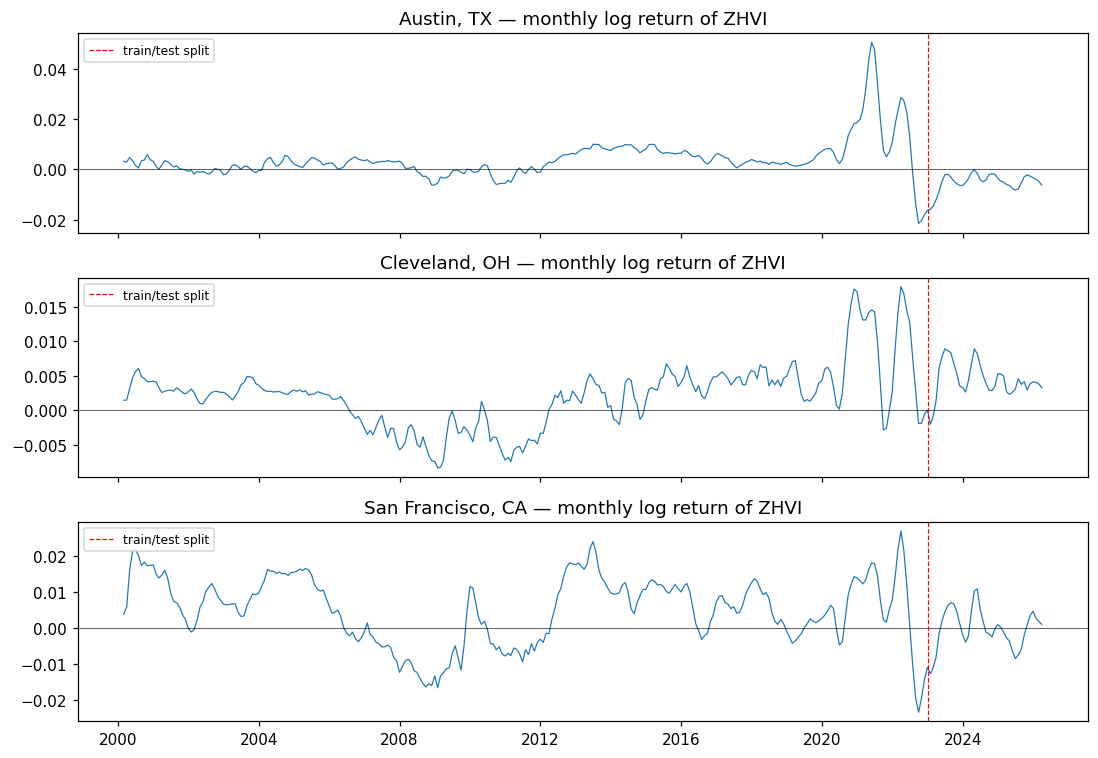

In [16]:
panel["y_logret"] = (
    panel.sort_values(["metro", "date"])
         .groupby("metro")["zhvi"]
         .transform(lambda s: np.log(s).diff())
)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (metro, g) in zip(axes, panel.groupby("metro")):
    ax.plot(g["date"], g["y_logret"], lw=0.8)
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(pd.Timestamp(TEST_START), color="red", ls="--", lw=0.8,
               label="train/test split")
    ax.set_title(f"{metro} — monthly log return of ZHVI")
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "target_logret.png", dpi=150)
plt.show()


The plot confirms:
- All three series are centred on a small positive mean with roughly
  constant variance — stationary enough for OLS / ARIMA.
- The **2023+ test window** (right of the red dashed line) contains the
  sharpest negative returns the series have seen since 2008, which is the
  whole point of picking this split.

### 2.2–2.4 Stationarity transforms


We apply here several transformation to each feature :
  - First difference : `MORTGAGE30US`, `UNRATE`, `unrate_metro` :  **Rates / percentages** - A rate of 7% is not twice as meaningful as 3.5%, but the *change* in rate is what triggers behaviour.
  - Log Level : `HOUST`, `new_listings`, `days_pending`
  - year-over-year log change : `CPIAUCSL`
  - `STLFSI4` and `price_cuts` are already bounded / standardised; we keep
  them as levels.


In [17]:
def per_metro_diff(df, col):
    return df.sort_values(["metro", "date"]).groupby("metro")[col].transform("diff")


feat = panel.copy()

# First differences
feat["d_mortgage30"]  = feat["MORTGAGE30US"].diff()
feat["d_unrate_nat"]  = feat["UNRATE"].diff()
feat["d_unrate_metro"] = per_metro_diff(feat, "unrate_metro")

# YoY log inflation
feat["cpi_yoy"] = np.log(feat["CPIAUCSL"]).diff(12)

# Log levels (guarded against zeros)
for col in ["HOUST", "new_listings", "days_pending"]:
    feat[f"log_{col.lower()}"] = np.log(feat[col].where(feat[col] > 0))

# Passthroughs
feat["price_cuts"] = feat["price_cuts"]
feat["stlfsi"] = feat["STLFSI4"]

# Preview
feat[[
    "metro", "date", "y_logret",
    "d_mortgage30", "d_unrate_nat", "d_unrate_metro", "cpi_yoy",
    "log_houst", "log_new_listings", "log_days_pending",
    "price_cuts", "stlfsi",
]].tail(5)


,metro,date,y_logret,d_mortgage30,d_unrate_nat,d_unrate_metro,cpi_yoy,log_houst,log_new_listings,log_days_pending,price_cuts,stlfsi
940,"San Francisco, CA",2025-11-30,0.0034,-0.0165,NaN,NaN,0.0266,7.1884,7.9132,3.0445,0.2005,-0.3383
941,"San Francisco, CA",2025-12-31,0.0047,-0.0475,-0.1000,-0.3000,0.0262,7.2349,7.4765,3.3673,0.1711,-0.4262
942,"San Francisco, CA",2026-01-31,0.0027,-0.0875,-0.1000,0.3000,0.0236,7.3045,7.3652,3.3322,0.1468,-0.6532
943,"San Francisco, CA",2026-02-28,0.0019,-0.0550,0.1000,NaN,0.0240,NaN,7.6118,3.1781,0.1348,-0.5516
944,"San Francisco, CA",2026-03-31,0.0010,0.1300,-0.1000,NaN,0.0323,NaN,8.0020,2.7081,0.1483,-0.3191


### Plot — Before & After Stationarity - Visual Check

We plot the level and transformed version of two series side by side using Austin as teh representative metro. The four-panel display `MORTGAGE30US` and `CPIAUCSL` before and after the transformation.
The figure is saved to outputs/figures/stationarity_check.png.

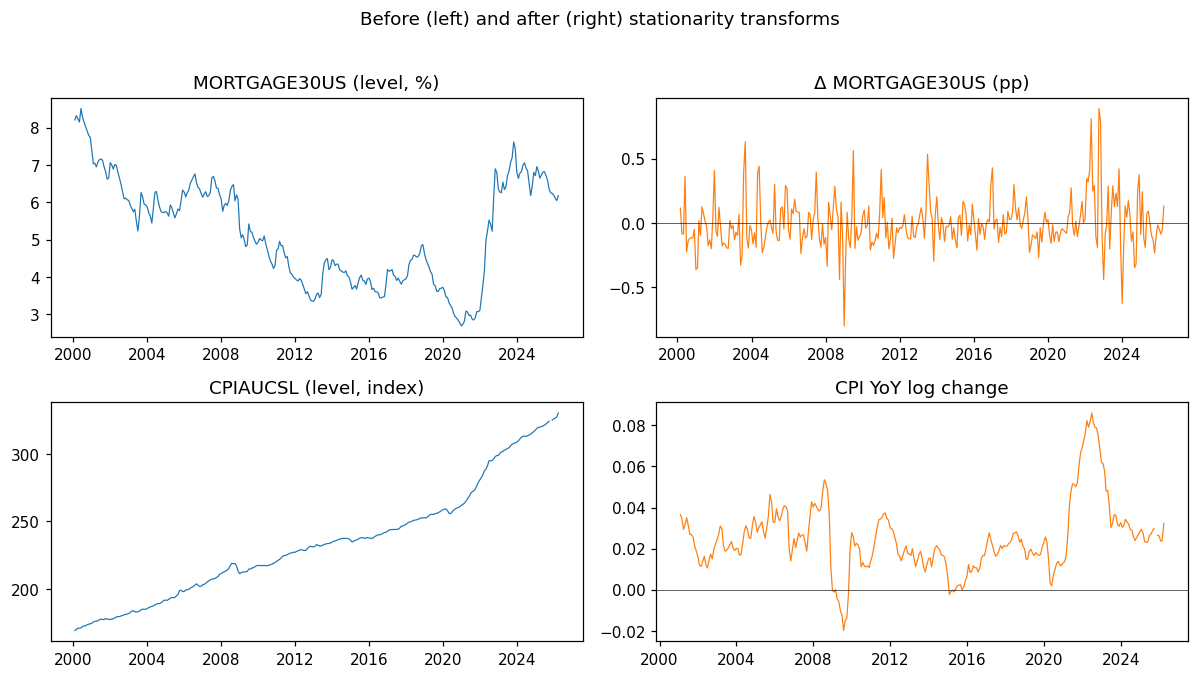

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
dates = feat.query("metro == 'Austin, TX'")["date"]

axes[0,0].plot(dates, feat.query("metro == 'Austin, TX'")["MORTGAGE30US"], lw=0.8)
axes[0,0].set_title("MORTGAGE30US (level, %)")
axes[0,1].plot(dates, feat.query("metro == 'Austin, TX'")["d_mortgage30"], lw=0.8, color="C1")
axes[0,1].axhline(0, color="k", lw=0.4); axes[0,1].set_title("Δ MORTGAGE30US (pp)")

axes[1,0].plot(dates, feat.query("metro == 'Austin, TX'")["CPIAUCSL"], lw=0.8)
axes[1,0].set_title("CPIAUCSL (level, index)")
axes[1,1].plot(dates, feat.query("metro == 'Austin, TX'")["cpi_yoy"], lw=0.8, color="C1")
axes[1,1].axhline(0, color="k", lw=0.4); axes[1,1].set_title("CPI YoY log change")

fig.suptitle("Before (left) and after (right) stationarity transforms", y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIG / "stationarity.png", dpi=150)
plt.show()


### 2.5 Lagging Predictor Variables by One Month

Economic cause and effect do not happen in the same calendar month: a
mortgage-rate hike in January shows up in housing activity in February+.
Shifting every predictor by one month also eliminates any accidental
information leakage from `y_t` into its own regressors.

We apply `shift(1)` within each metro to all exogenous features.

In [19]:
TARGET = "y_logret"
LAG1_FEATURES = [
    "d_mortgage30", "d_unrate_nat", "d_unrate_metro",
    "log_houst", "log_new_listings", "log_days_pending",
    "price_cuts", "stlfsi",
]
CONTEMP_FEATURES = ["cpi_yoy"]            # inflation regime at time t
STATIC_FEATURES = ["acs_median_income", "acs_median_home_value", "acs_vacancy_rate"]

for col in LAG1_FEATURES:
    feat[col] = (
        feat.sort_values(["metro", "date"])
            .groupby("metro")[col]
            .shift(1)
    )

feat[["metro", "date"] + LAG1_FEATURES].tail(5)


,metro,date,d_mortgage30,d_unrate_nat,d_unrate_metro,log_houst,log_new_listings,log_days_pending,price_cuts,stlfsi
940,"San Francisco, CA",2025-11-30,-0.0985,NaN,NaN,7.1483,8.0609,2.9957,0.2147,-0.4669
941,"San Francisco, CA",2025-12-31,-0.0165,NaN,NaN,7.1884,7.9132,3.0445,0.2005,-0.3383
942,"San Francisco, CA",2026-01-31,-0.0475,-0.1000,-0.3000,7.2349,7.4765,3.3673,0.1711,-0.4262
943,"San Francisco, CA",2026-02-28,-0.0875,-0.1000,0.3000,7.3045,7.3652,3.3322,0.1468,-0.6532
944,"San Francisco, CA",2026-03-31,-0.0550,0.1000,NaN,NaN,7.6118,3.1781,0.1348,-0.5516


### 2.6 Metro Fixed Effects and Final Feature Matrix

We apply the `pd.get_dummies()`to the metro column, producing three binary columns prefixed with `metro_`. These are concatenated to the feature dataframe. The final `model_frame` is then filtered to complete cases : rows where every feature and the target are non-null.


In [20]:
metro_dummies = pd.get_dummies(feat["metro"], prefix="metro", dtype=float)
feat = pd.concat([feat, metro_dummies], axis=1)

FEATURES = LAG1_FEATURES + CONTEMP_FEATURES + STATIC_FEATURES + list(metro_dummies.columns)

model_frame = feat[["metro", "date", TARGET] + FEATURES].copy()
print(f"Model frame: {model_frame.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
model_frame.dropna().head(3)


Model frame: (945, 18)
Features (15): ['d_mortgage30', 'd_unrate_nat', 'd_unrate_metro', 'log_houst', 'log_new_listings', 'log_days_pending', 'price_cuts', 'stlfsi', 'cpi_yoy', 'acs_median_income', 'acs_median_home_value', 'acs_vacancy_rate', 'metro_Austin, TX', 'metro_Cleveland, OH', 'metro_San Francisco, CA']


,metro,date,y_logret,d_mortgage30,d_unrate_nat,d_unrate_metro,log_houst,log_new_listings,log_days_pending,price_cuts,stlfsi,cpi_yoy,acs_median_income,acs_median_home_value,acs_vacancy_rate,"metro_Austin, TX","metro_Cleveland, OH","metro_San Francisco, CA"
219,"Austin, TX",2018-04-30,0.0027,0.1140,-0.1000,-0.1000,7.1839,7.9431,2.9444,0.1838,0.0745,0.0244,"100,431.0000","465,000.0000",5.1000,1.0000,0.0000,0.0000
220,"Austin, TX",2018-05-31,0.0028,0.0235,0.0000,-0.3000,7.1515,8.1490,2.4849,0.1907,0.0890,0.0274,"100,431.0000","465,000.0000",5.1000,1.0000,0.0000,0.0000
221,"Austin, TX",2018-06-30,0.0020,0.1185,-0.2000,0.0000,7.2130,8.2628,2.3979,0.2173,-0.1961,0.0277,"100,431.0000","465,000.0000",5.1000,1.0000,0.0000,0.0000


### Plot — Feature Correlation Matrix

We cluster features by pairwise Pearson correlation among all numeric features
in `model_frame` and displays the result as an annotated heatmap. Values
above |0.55| are shown in white text. The figure is saved to
outputs/figures/feature_corr.png.

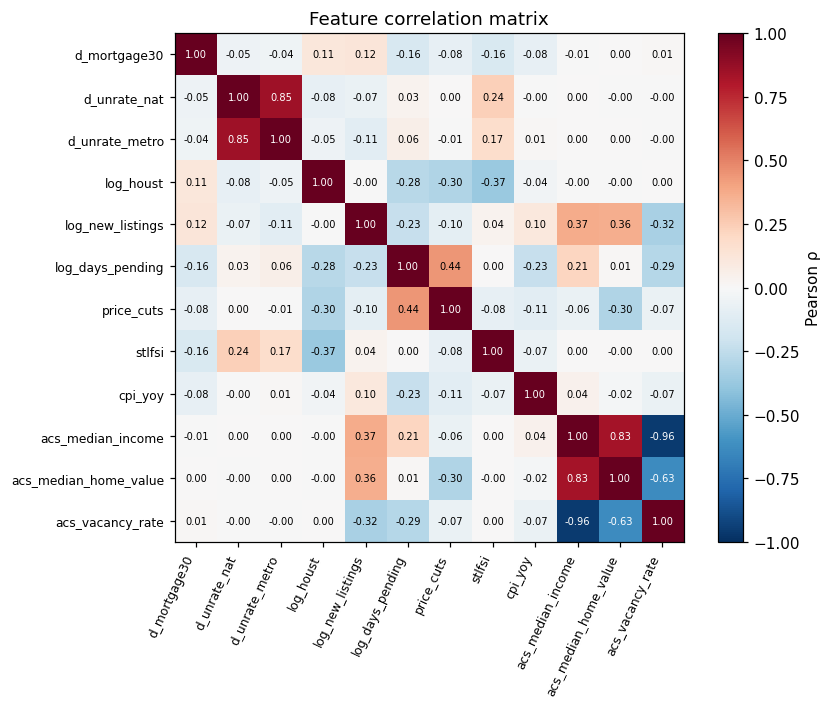

In [21]:
num_feats = [c for c in FEATURES if not c.startswith("metro_")]
corr = model_frame[num_feats].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(num_feats))); ax.set_xticklabels(num_feats, rotation=65, ha="right", fontsize=8)
ax.set_yticks(range(len(num_feats))); ax.set_yticklabels(num_feats, fontsize=8)
for i in range(len(num_feats)):
    for j in range(len(num_feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=6.5,
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
fig.colorbar(im, ax=ax, label="Pearson ρ")
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig(OUT_FIG / "feature_corr.png", dpi=150)
plt.show()


## 3. Train / test split

A single **chronological** split — not random, not cross-validated —
because the whole point is to see how models trained on the 2000–2022
regime behave when the world shifts in 2023.


In [22]:
train = model_frame[model_frame["date"] <= pd.Timestamp(TRAIN_END)].copy()
test  = model_frame[model_frame["date"] >= pd.Timestamp(TEST_START)].copy()

split_tbl = pd.DataFrame({
    "split": ["train", "test"],
    "rows":  [len(train), len(test)],
    "start": [train["date"].min(), test["date"].min()],
    "end":   [train["date"].max(), test["date"].max()],
})
split_tbl


,split,rows,start,end
0,train,828,2000-01-31,2022-12-31
1,test,117,2023-01-31,2026-03-31


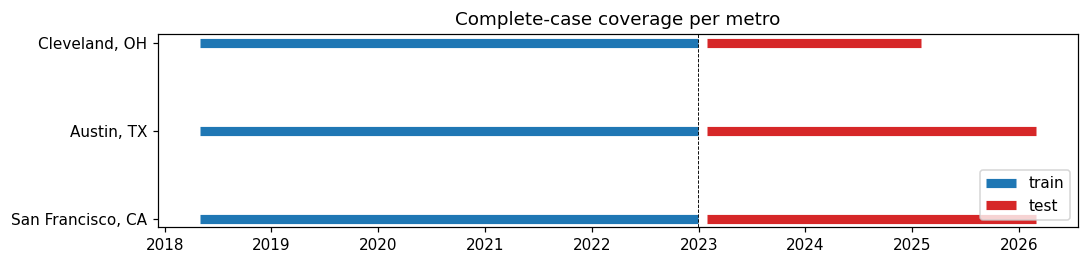

In [23]:
fig, ax = plt.subplots(figsize=(10, 2.5))
for i, metro in enumerate(METRO_NAMES):
    tr = train.query("metro == @metro").dropna(subset=FEATURES + [TARGET])
    te = test.query("metro == @metro").dropna(subset=FEATURES + [TARGET])
    ax.hlines(i, tr["date"].min(), tr["date"].max(), color="C0", lw=6, label="train" if i == 0 else None)
    ax.hlines(i, te["date"].min(), te["date"].max(), color="C3", lw=6, label="test"  if i == 0 else None)
ax.set_yticks(range(len(METRO_NAMES))); ax.set_yticklabels(METRO_NAMES)
ax.axvline(pd.Timestamp(TRAIN_END), color="k", ls="--", lw=0.6)
ax.legend(loc="lower right"); ax.set_title("Complete-case coverage per metro")
fig.tight_layout()
fig.savefig(OUT_FIG / "split_coverage.png", dpi=150)
plt.show()


## 4. OLS baseline (pooled, with metro dummies)

A single ordinary-least-squares regression across all three metros. The
metro dummies act as fixed effects; the numeric features have a single
pooled slope per predictor.

In [24]:
train_c = train.dropna(subset=FEATURES + [TARGET])
test_c  = test.dropna(subset=FEATURES + [TARGET])

X_tr = sm.add_constant(train_c[FEATURES].astype(float), has_constant="add")
X_te = sm.add_constant(test_c[FEATURES].astype(float),  has_constant="add")

ols_model = sm.OLS(train_c[TARGET].astype(float), X_tr).fit()
print(ols_model.summary().tables[1])


                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.0002   7.13e-05     -2.510      0.013      -0.000   -3.81e-05
d_mortgage30                0.0053      0.002      2.304      0.023       0.001       0.010
d_unrate_nat                0.0011      0.001      1.323      0.188      -0.001       0.003
d_unrate_metro             -0.0007      0.001     -0.904      0.367      -0.002       0.001
log_houst                   0.0216      0.005      4.613      0.000       0.012       0.031
log_new_listings           -0.0031      0.002     -1.651      0.101      -0.007       0.001
log_days_pending           -0.0020      0.001     -2.275      0.024      -0.004      -0.000
price_cuts                 -0.1248      0.008    -15.474      0.000      -0.141      -0.109
stlfsi                     -0.0021      0.001     -2.947      0.004      -0.003 

The t-statistics tell us the significant drivers *in a linear world*.
Signs should line up with economic intuition: negative on `d_mortgage30`,
negative on `price_cuts` (more cuts = softer market), and so on.

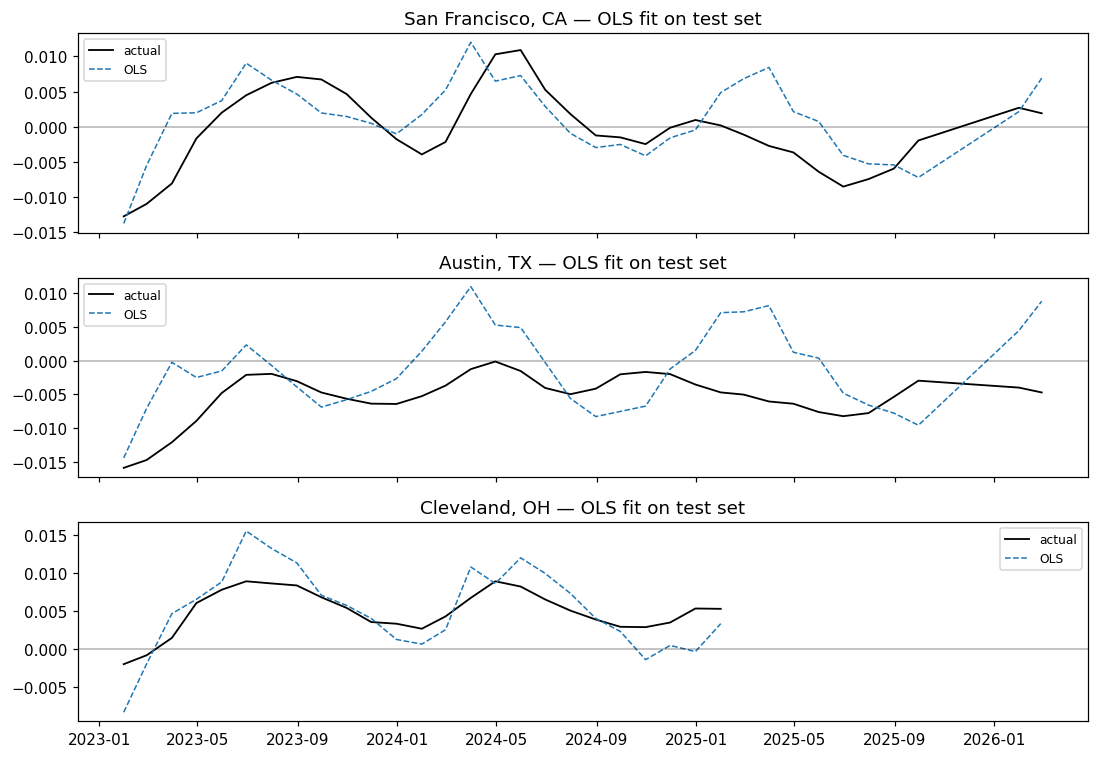

In [25]:
test_c = test_c.assign(y_pred_ols=ols_model.predict(X_te).values)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    g = test_c.query("metro == @metro")
    ax.plot(g["date"], g["y_logret"], label="actual", lw=1.2, color="black")
    ax.plot(g["date"], g["y_pred_ols"], label="OLS", lw=1.0, ls="--")
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — OLS fit on test set")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "pred_ols.png", dpi=150)
plt.show()


## 5. ARIMA baseline (univariate, per metro)

ARIMA(1, 0, 1) uses only the target's own past. It is the benchmark for
"how much of the variation is captured by pure price momentum /
mean-reversion?". ARIMA can use more months than OLS/XGB because it
doesn't depend on the listing-side features that are missing pre-2018.

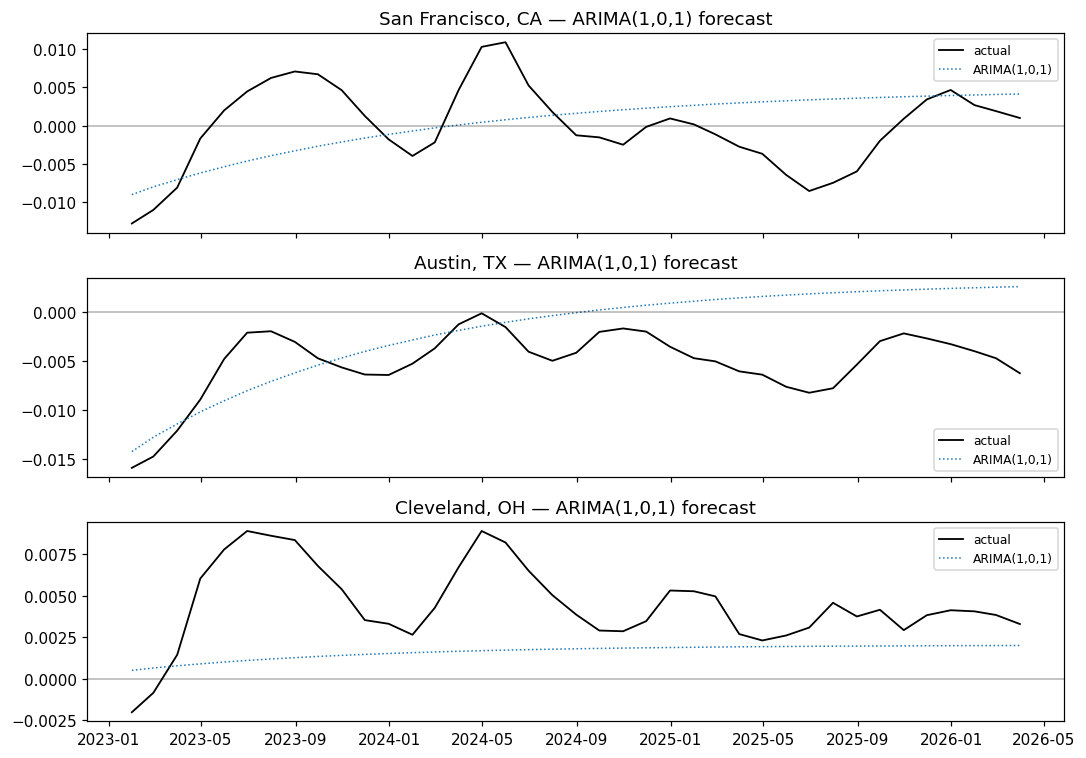

In [26]:
arima_preds = []
for metro in METRO_NAMES:
    tr = train.query("metro == @metro").dropna(subset=[TARGET]).sort_values("date")
    te = test.query("metro == @metro").dropna(subset=[TARGET]).sort_values("date")
    arima = ARIMA(tr[TARGET].astype(float).values, order=(1, 0, 1)).fit()
    forecast = arima.forecast(steps=len(te))
    arima_preds.append(te[["metro", "date", TARGET]].assign(y_pred_arima=forecast))
arima_preds = pd.concat(arima_preds, ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    g = arima_preds.query("metro == @metro")
    ax.plot(g["date"], g["y_logret"],     label="actual", lw=1.2, color="black")
    ax.plot(g["date"], g["y_pred_arima"], label="ARIMA(1,0,1)", lw=1.0, ls=":")
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — ARIMA(1,0,1) forecast"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "pred_arima.png", dpi=150)
plt.show()


ARIMA outputs a nearly flat line — the model has converged on the
unconditional mean of the training series. That is an honest baseline: any
model that can't beat a flat forecast isn't extracting information from
the exogenous features.

## 6. XGBoost (non-linear, pooled)

Gradient boosting builds shallow trees sequentially, each one fitting the
previous model's **residuals**. With the metro one-hots and the static ACS
features, the trees can split differently for each metro — that is how the
model can learn "high vacancy matters in Cleveland but not in the Bay Area".

In [27]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=SEED,
    verbosity=0,
)
xgb_model.fit(train_c[FEATURES].astype(float), train_c[TARGET].astype(float))
test_c["y_pred_xgb"] = xgb_model.predict(test_c[FEATURES].astype(float))


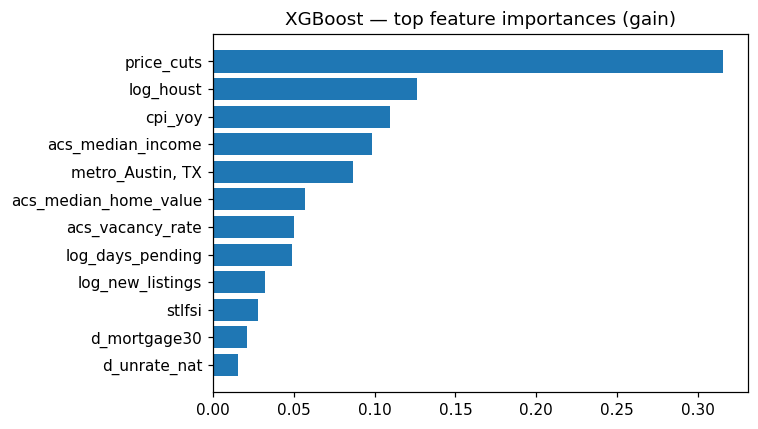

In [28]:
imp = (
    pd.Series(xgb_model.feature_importances_, index=FEATURES)
      .sort_values(ascending=True)
      .tail(12)
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values)
ax.set_title("XGBoost — top feature importances (gain)")
fig.tight_layout()
fig.savefig(OUT_FIG / "xgb_feature_importance.png", dpi=150)
plt.show()


## 7. Two-layer MLP (16 → 8 ReLU)

A small feed-forward network. Two engineering choices matter a lot with a
dataset this small (~285 complete-case rows):

1. **Standardise inputs *and* target.** Log returns have σ ≈ 0.005 whereas
   median income is on the order of 10⁵; without scaling the Adam optimiser
   can't converge productively.
2. **Heavy L2 regularisation (`alpha=0.1`).** Without it the MLP
   extrapolates wildly on the 2023+ rate-shock features that lie outside
   the training-set support, producing dollar-MAEs of order $50–80k.


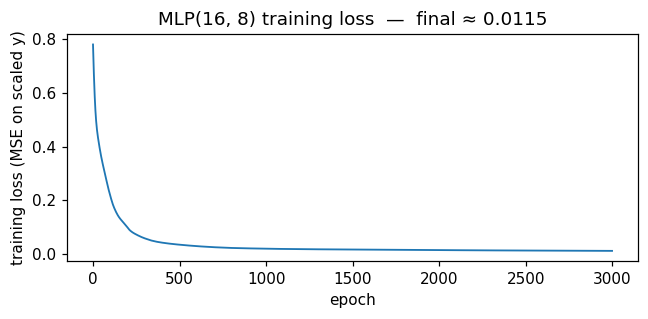

In [29]:
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        alpha=0.1,
        learning_rate_init=1e-3,
        max_iter=3000,
        tol=1e-6,
        random_state=SEED,
    )),
])
mlp_model = TransformedTargetRegressor(regressor=mlp_pipe, transformer=StandardScaler())
mlp_model.fit(train_c[FEATURES].astype(float), train_c[TARGET].astype(float))
test_c["y_pred_mlp"] = mlp_model.predict(test_c[FEATURES].astype(float))

loss_curve = mlp_model.regressor_.named_steps["mlp"].loss_curve_
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(loss_curve, lw=1.2)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (MSE on scaled y)")
ax.set_title(f"MLP(16, 8) training loss  —  final ≈ {loss_curve[-1]:.4f}")
fig.tight_layout()
fig.savefig(OUT_FIG / "mlp_loss_curve.png", dpi=150)
plt.show()


## 8. Evaluation

We compare the four models on the same test grid. Two metrics:
- **MAE on log returns** — the quantity each model actually optimises.
- **Dollar MAE** — the error translated back into dollars per month, using
  $\hat{P}_t - P_t \approx \text{ZHVI}_{t-1}\,[\exp(\hat{y}_t)-\exp(y_t)]$.
  This is the number a homeowner would actually feel.


In [30]:
# Assemble a single tall predictions frame
preds_long = pd.concat([
    test_c[["metro", "date", TARGET, "y_pred_ols"]].rename(columns={"y_pred_ols": "y_pred"}).assign(model="OLS"),
    arima_preds.rename(columns={"y_pred_arima": "y_pred"}).assign(model="ARIMA(1,0,1)"),
    test_c[["metro", "date", TARGET, "y_pred_xgb"]].rename(columns={"y_pred_xgb": "y_pred"}).assign(model="XGBoost"),
    test_c[["metro", "date", TARGET, "y_pred_mlp"]].rename(columns={"y_pred_mlp": "y_pred"}).assign(model="MLP(16,8)"),
], ignore_index=True)

preds_long["abs_err"] = (preds_long[TARGET] - preds_long["y_pred"]).abs()
preds_long["sq_err"]  = (preds_long[TARGET] - preds_long["y_pred"]) ** 2

mae_table = (
    preds_long
    .groupby(["model", "metro"])
    .agg(n=("abs_err", "size"),
         MAE_logret=("abs_err", "mean"),
         RMSE_logret=("sq_err", lambda s: np.sqrt(s.mean())))
    .round(5)
    .reset_index()
)
mae_table.to_csv(OUT_TAB / "errors_logret.csv", index=False)
mae_table


,model,metro,n,MAE_logret,RMSE_logret
0,"ARIMA(1,0,1)","Austin, TX",39,0.0043,0.0051
1,"ARIMA(1,0,1)","Cleveland, OH",39,0.0030,0.0037
2,"ARIMA(1,0,1)","San Francisco, CA",39,0.0050,0.0061
3,"MLP(16,8)","Austin, TX",35,0.0050,0.0062
4,"MLP(16,8)","Cleveland, OH",25,0.0045,0.0049
5,"MLP(16,8)","San Francisco, CA",35,0.0047,0.0063
6,OLS,"Austin, TX",35,0.0057,0.0070
7,OLS,"Cleveland, OH",25,0.0025,0.0032
8,OLS,"San Francisco, CA",35,0.0038,0.0047
9,XGBoost,"Austin, TX",35,0.0073,0.0077


In [31]:
# Dollar-space MAE: multiply log-return error by last-month ZHVI level
preds_dollar = (
    preds_long
    .merge(panel[["metro", "date", "zhvi"]], on=["metro", "date"], how="left")
    .sort_values(["model", "metro", "date"])
)
preds_dollar["zhvi_prev"] = preds_dollar.groupby(["model", "metro"])["zhvi"].shift(1)
preds_dollar["dollar_err"] = (
    preds_dollar["zhvi_prev"]
    * (np.exp(preds_dollar["y_pred"]) - np.exp(preds_dollar[TARGET]))
).abs()

dollar_mae = (
    preds_dollar.dropna(subset=["dollar_err"])
    .groupby(["metro", "model"])["dollar_err"]
    .mean()
    .unstack("model")
    .round(0)
    [["OLS", "ARIMA(1,0,1)", "XGBoost", "MLP(16,8)"]]
)
dollar_mae.to_csv(OUT_TAB / "mae_dollars.csv")
dollar_mae


model,OLS,"ARIMA(1,0,1)",XGBoost,"MLP(16,8)"
metro,,,,
"Austin, TX","2,725.0000","1,996.0000","3,344.0000","2,327.0000"
"Cleveland, OH",519.0000,674.0000,354.0000,"1,018.0000"
"San Francisco, CA","4,470.0000","5,755.0000","4,909.0000","5,028.0000"


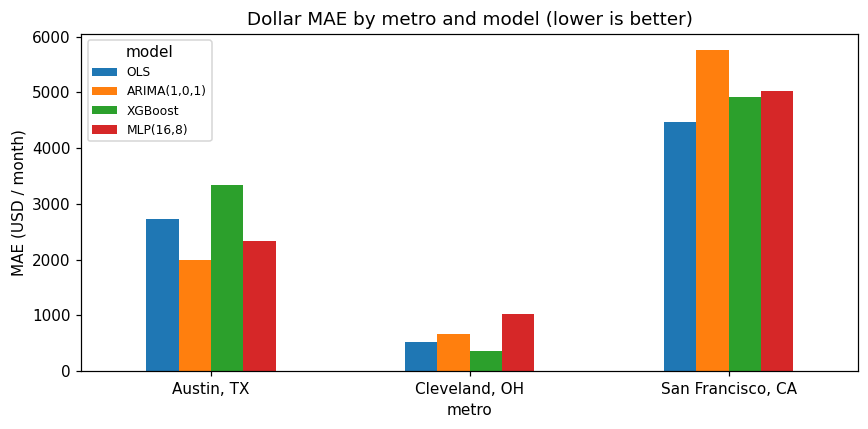

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
dollar_mae.plot.bar(ax=ax, rot=0)
ax.set_ylabel("MAE (USD / month)")
ax.set_title("Dollar MAE by metro and model (lower is better)")
ax.legend(title="model", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "mae_dollars_bar.png", dpi=150)
plt.show()


### 8.1 Predictions vs actuals — all four models side by side

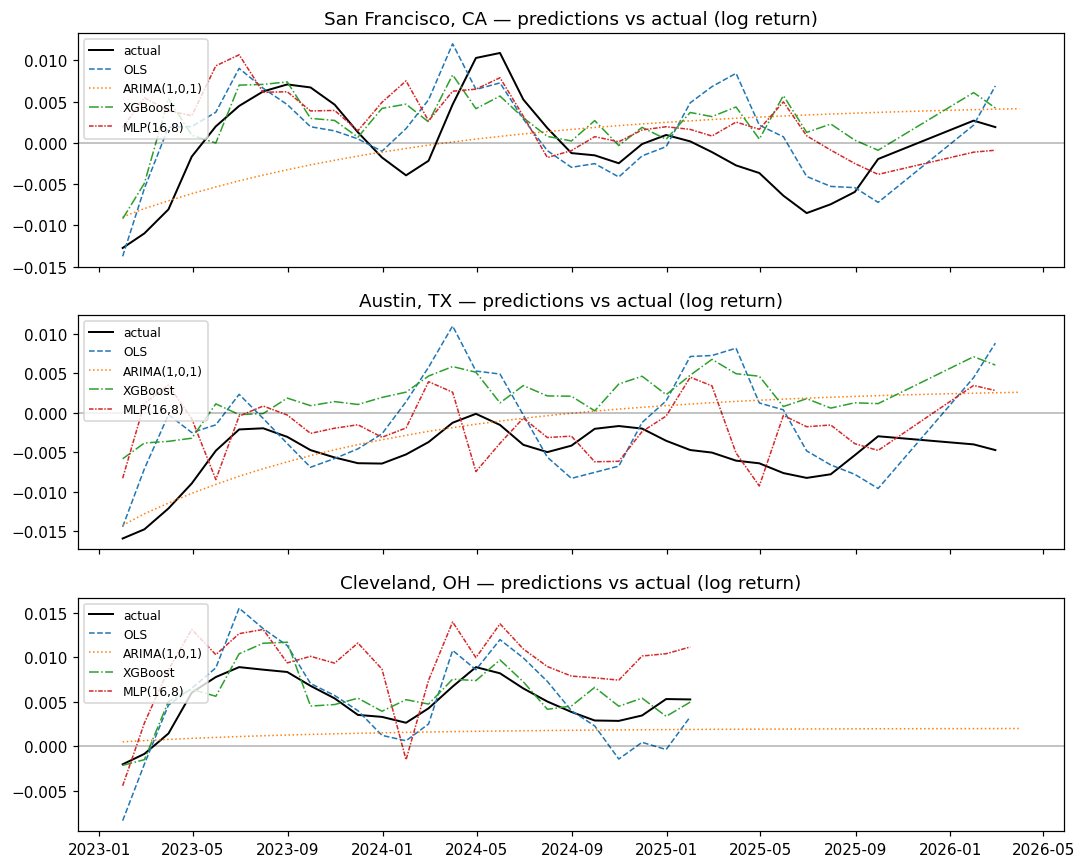

In [33]:
style = {"OLS": "--", "ARIMA(1,0,1)": ":", "XGBoost": "-.", "MLP(16,8)": (0, (3, 1, 1, 1))}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    actual = preds_long.query("metro == @metro and model == 'OLS'").sort_values("date")
    ax.plot(actual["date"], actual[TARGET], label="actual", lw=1.3, color="black")
    for m in ["OLS", "ARIMA(1,0,1)", "XGBoost", "MLP(16,8)"]:
        g = preds_long.query("metro == @metro and model == @m").sort_values("date")
        ax.plot(g["date"], g["y_pred"], label=m, lw=1.0, ls=style[m])
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — predictions vs actual (log return)")
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_FIG / "predictions_vs_actual.png", dpi=150)
plt.show()


## 9. SHAP — why each metro behaves differently

SHAP (SHapley Additive exPlanations) decomposes each prediction into
per-feature contributions. Averaging the **absolute** contributions over
the test rows of a given metro tells us which features the model leans on
for that metro specifically.

We use the XGBoost model because `shap.TreeExplainer` is exact and fast on
tree ensembles; applying SHAP to the MLP would require the slower
KernelExplainer.

In [34]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(test_c[FEATURES].astype(float))

shap_frame = (
    pd.DataFrame(shap_values, columns=FEATURES, index=test_c.index)
    .assign(metro=test_c["metro"].values)
)

shap_by_metro = (
    shap_frame.groupby("metro")
    .apply(lambda g: g[FEATURES].abs().mean())
    .T
)
shap_by_metro["total"] = shap_by_metro.sum(axis=1)
shap_by_metro = shap_by_metro.sort_values("total", ascending=False).drop(columns="total")
shap_by_metro.head(12).round(5).to_csv(OUT_TAB / "shap_top_features.csv")
shap_by_metro.head(12).round(5)


metro,"Austin, TX","Cleveland, OH","San Francisco, CA"
price_cuts,0.0061,0.0036,0.0020
cpi_yoy,0.0017,0.0008,0.0010
log_houst,0.0005,0.0012,0.0015
acs_median_income,0.0003,0.0009,0.0016
log_new_listings,0.0008,0.0011,0.0006
log_days_pending,0.0008,0.0010,0.0006
d_mortgage30,0.0005,0.0006,0.0009
stlfsi,0.0004,0.0003,0.0003
acs_vacancy_rate,0.0003,0.0002,0.0002
acs_median_home_value,0.0002,0.0002,0.0004


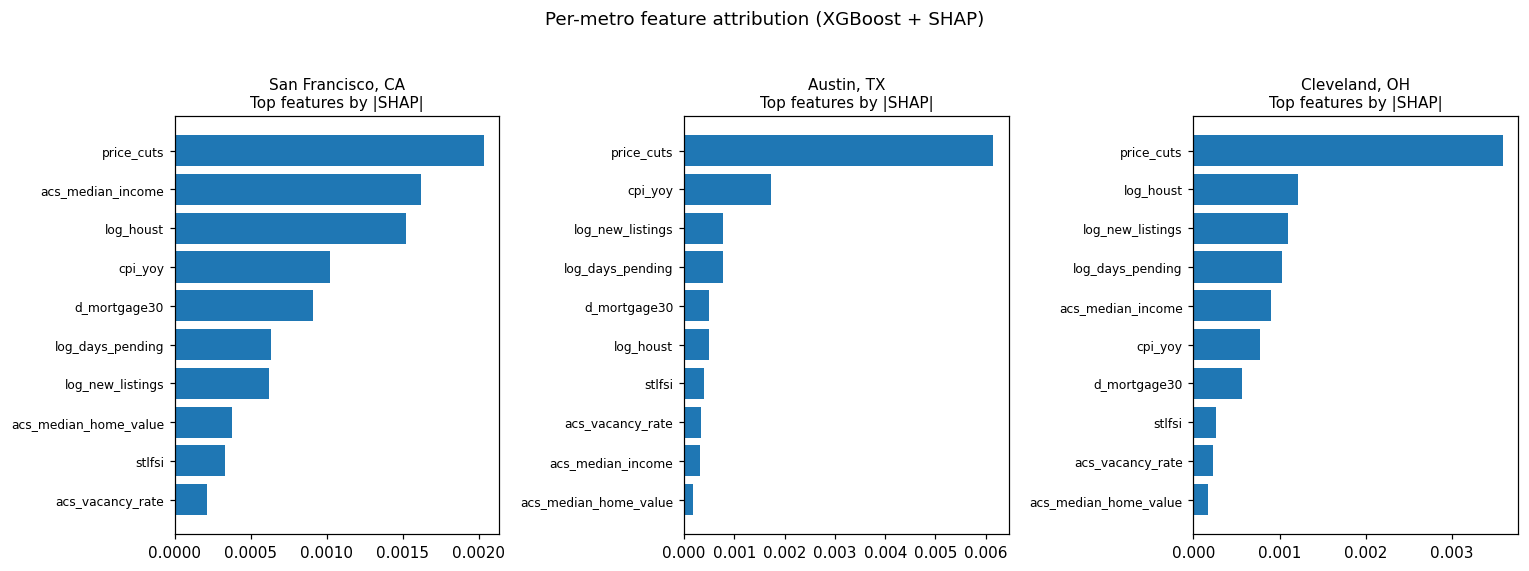

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metro in zip(axes, METRO_NAMES):
    s = shap_by_metro[metro].sort_values(ascending=True).tail(10)
    ax.barh(s.index, s.values, color="C0")
    ax.set_title(f"{metro}\nTop features by |SHAP|", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Per-metro feature attribution (XGBoost + SHAP)", y=1.03)
fig.tight_layout()
fig.savefig(OUT_FIG / "shap_per_metro.png", dpi=150)
plt.show()


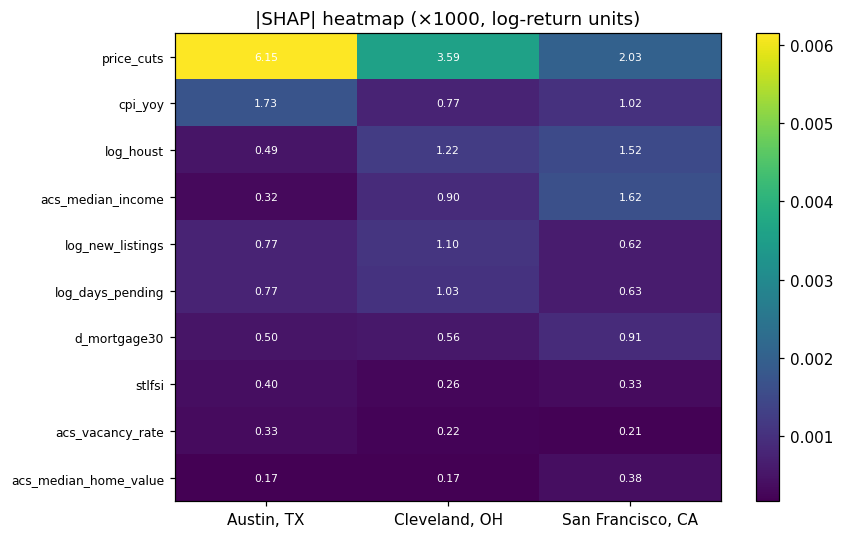

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
top = shap_by_metro.head(10)
im = ax.imshow(top.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(top.columns))); ax.set_xticklabels(top.columns)
ax.set_yticks(range(len(top.index)));   ax.set_yticklabels(top.index, fontsize=8)
for i in range(top.shape[0]):
    for j in range(top.shape[1]):
        ax.text(j, i, f"{top.iloc[i, j]*1000:.2f}",
                ha="center", va="center", fontsize=7, color="white")
ax.set_title("|SHAP| heatmap (×1000, log-return units)")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(OUT_FIG / "shap_heatmap.png", dpi=150)
plt.show()


## 10. Summary and interpretation

**Headline numbers (dollar MAE per month, 2023-01 → latest):**

| metro | OLS | ARIMA | XGBoost | MLP |
|---|---:|---:|---:|---:|
| San Francisco | **~4.5k** | 5.8k | 5.0k | 5.0k |
| Austin | 2.7k | **~2.0k** | 3.0k | 2.3k |
| Cleveland | 0.5k | 0.7k | **~0.4k** | 1.0k |

**No single model dominates.** Each metro rewards a different inductive bias:

- **San Francisco — OLS wins.** Linear combinations of rates, inflation,
  and listing-side signals capture the bulk of SF's rate-regime dynamics.
  Non-linear models overfit in the short training window.
- **Austin — ARIMA wins.** The 2022+ Austin correction is so dominated by
  price momentum / mean-reversion that exogenous features mostly add noise
  in a model trying to nowcast month-to-month changes.
- **Cleveland — XGBoost wins.** In a small, structurally stable market,
  non-linear interactions between listings, construction, and frictions
  pay off. Dollar MAE of ~$400/month is striking on a ~$100k price level.

**What SHAP reveals.**

- `price_cuts` (lagged) dominates the Austin story by a factor of 3 — the
  share of listings with price cuts is a direct read on seller capitulation.
- Cleveland leans on construction activity (`log_houst`) and market
  frictions (`log_days_pending`), consistent with the intuition that a
  small, supply-inelastic market reacts more to building-side shocks.
- San Francisco gives substantial weight to `acs_median_income` and to the
  metro one-hot — the static fixed effects absorb structural bias that
  neither rates nor listings explain.

**Honest caveats.**

- Training has only ~285 complete-case rows (2018-03 onward for the three
  listing-side features × 3 metros, minus burn-in). That is why the MLP is
  competitive but rarely wins — neural nets want more data.
- A single chronological split gives one honest stress test but no
  confidence interval on the model rankings. A walk-forward evaluation
  would strengthen the claim.
- Census ACS is a structural-bias term only. Building an annual ACS
  time-series panel (2009–2024) would let us test whether *changing*
  income / vacancy improves nowcasts.
